In [1]:
import os as os
import sys
import numpy as np

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

import math as math

from scripts.readTdi import readTdi, getTdiPath
from scripts.wosa import wosa
from scripts.lpsd import lpsd
from scripts.psdNoise import n_time_noise_from_psd, n_noise_psds, compute_psd_noise_distribution
from scripts.plot import plot, plot_psd_noise_median_histogram,  plot_psd_noise_median_histogram_two_cross_two, plot_scaled_median_vs_mean_pdf, plot_unscaled_median_vs_mean_pdf
from scripts.medianFuncs import confidence_interval, median_pdf, ratio_numerical
from scipy.special import digamma        # ψ(x) = H_{x-1} - γ
import matplotlib.pyplot as plt

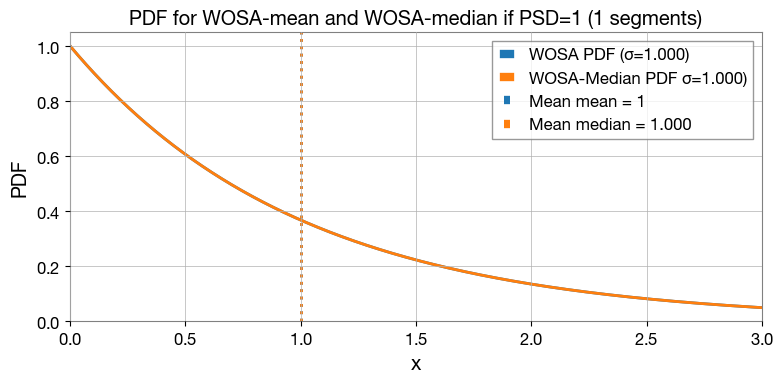

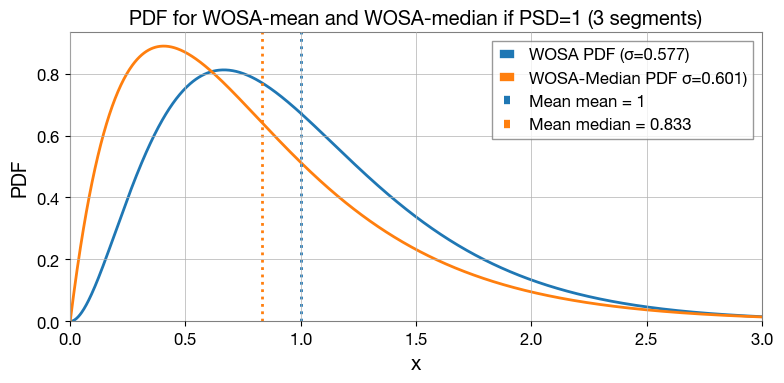

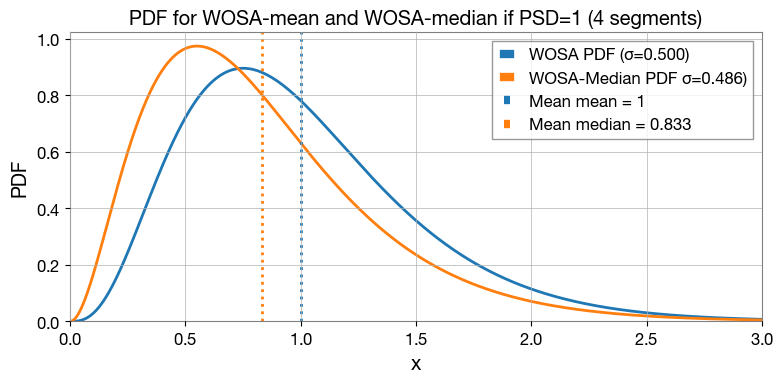

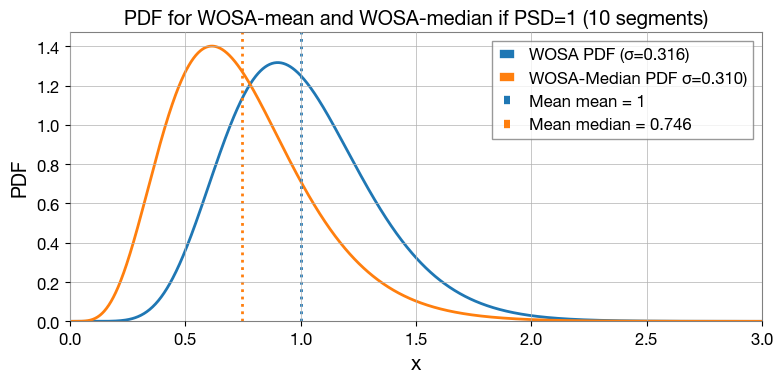

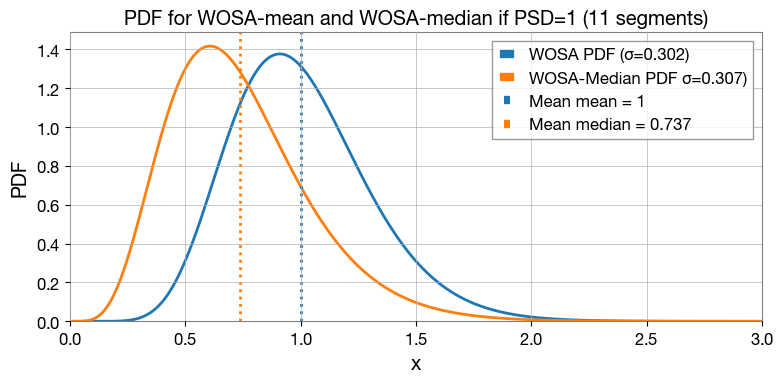

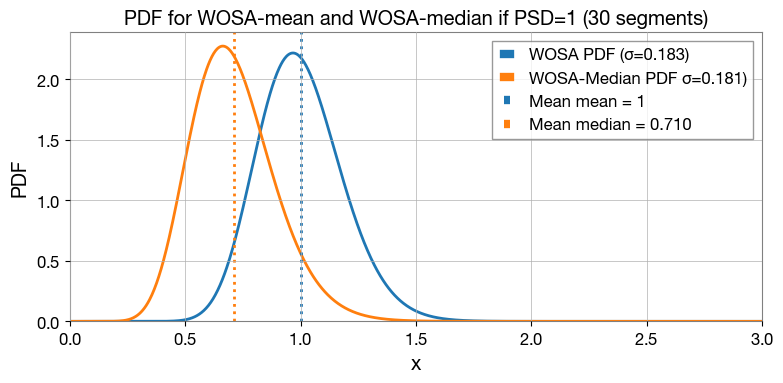

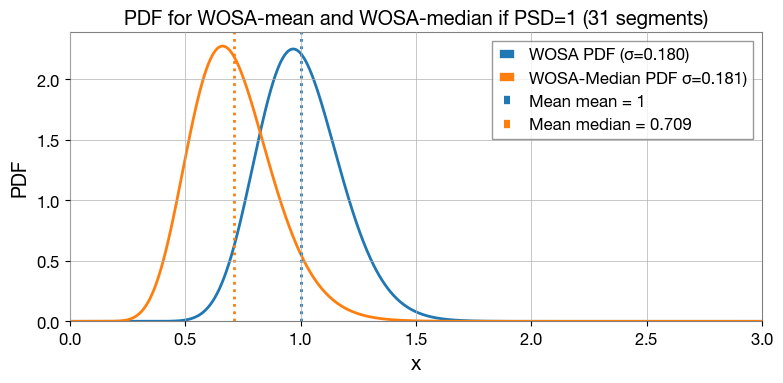

In [2]:
for N in (1, 3, 4, 10, 11, 30, 31):
    plot_unscaled_median_vs_mean_pdf(N, s=1)

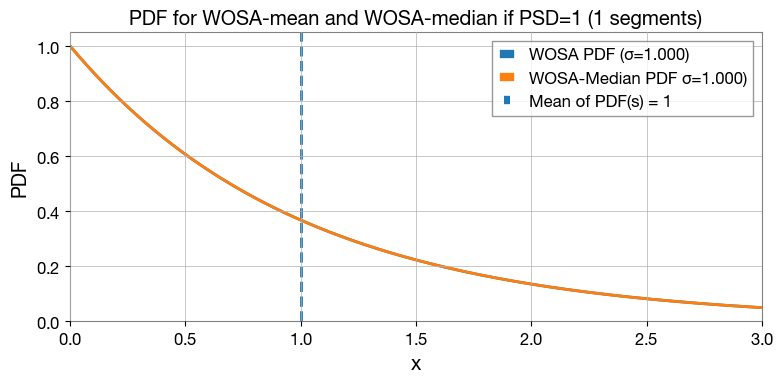

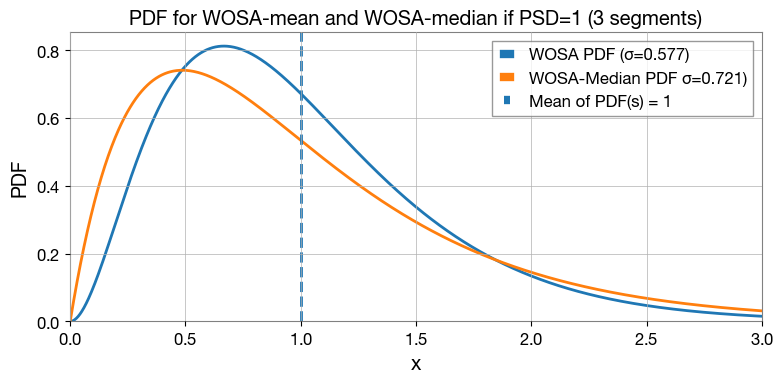

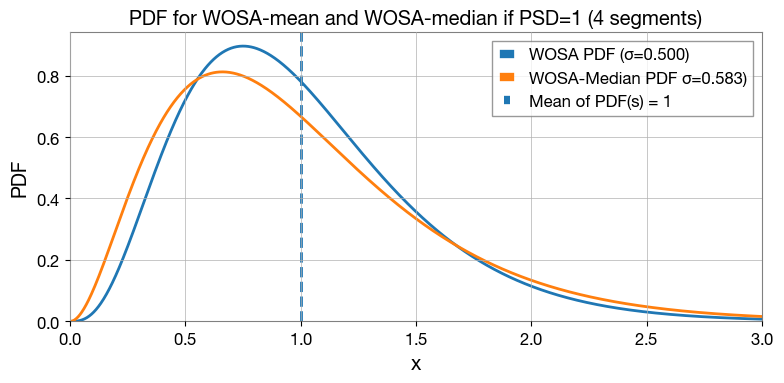

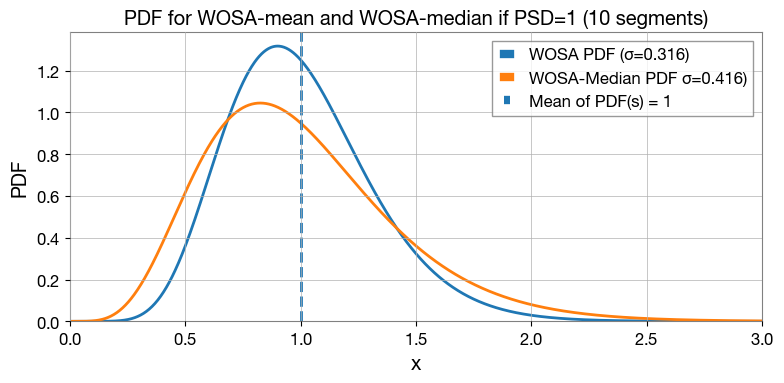

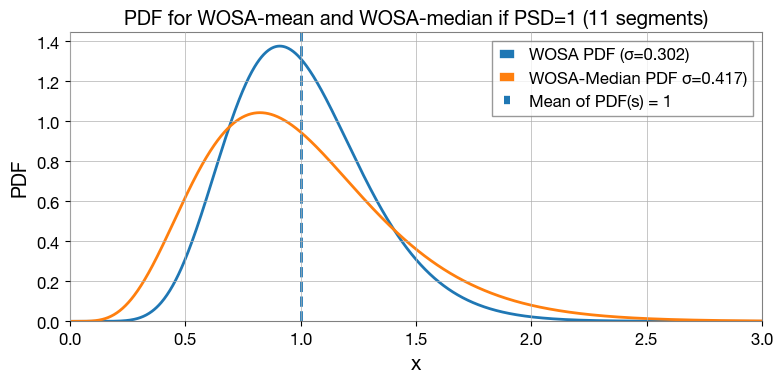

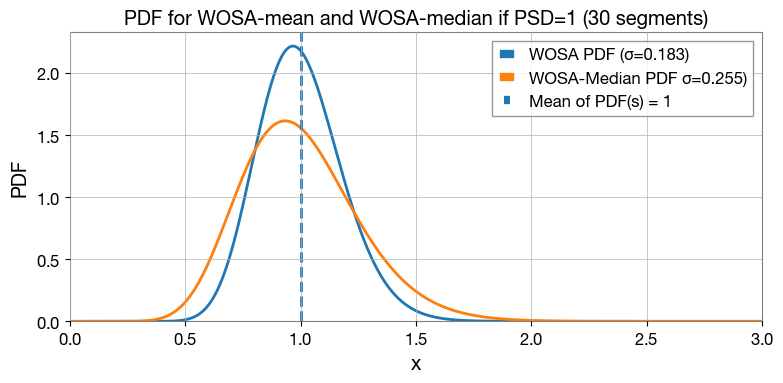

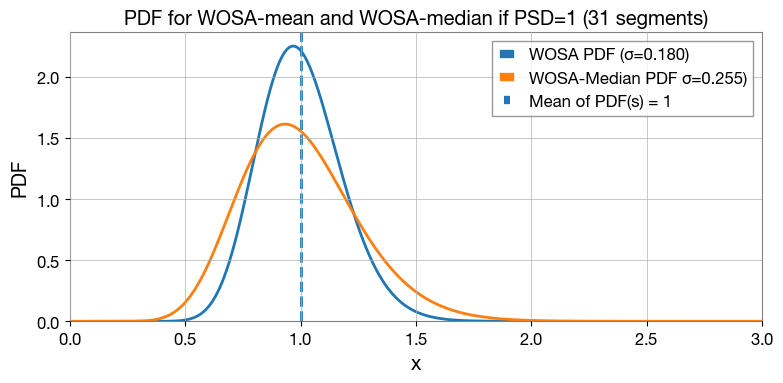

In [2]:
for N in (1, 3, 4, 10, 11, 30, 31):
    plot_scaled_median_vs_mean_pdf(N, s=1)

In [2]:
# 1) Read the TDI time series
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg
) 

#plot(data, t, fs, f_orig, orig_psd,  nperseg, title="TDI-X", bigtitle="PSD graphs")

# 3) generate n time-domain noise realisations such that PSD equals "PSD OF TDI time series "
time_noises = n_time_noise_from_psd(
    orig_psd, 
    fs, 
    nperseg, 
    n=1000,
    seed_offset=0
)

In [9]:
f_lpsd, psd_lpsd, L, D = lpsd(x=data, fs=fs)

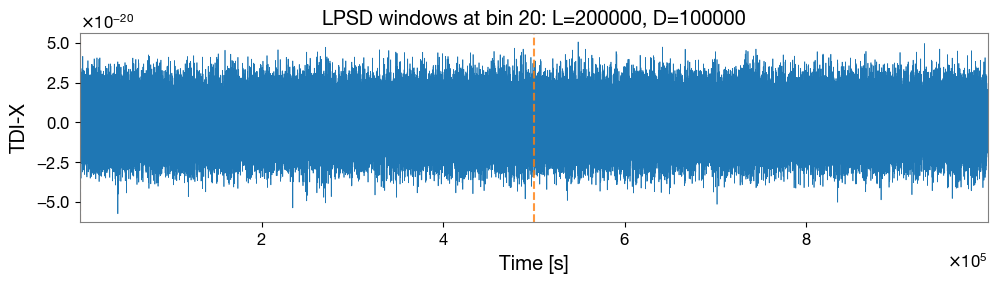

In [10]:
draw_segments_lpsd(t, data, L, D, bin_idx=20)

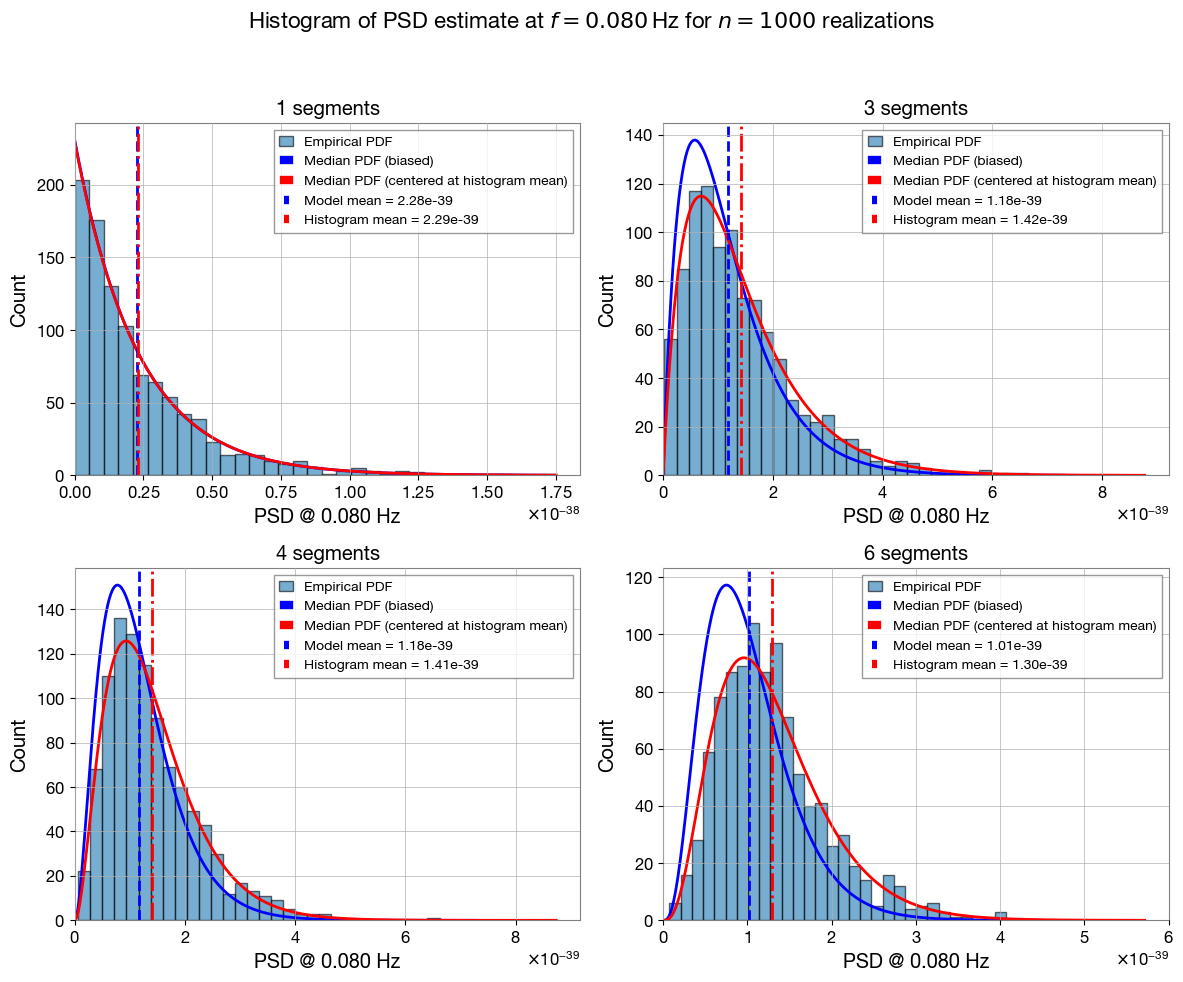

In [3]:
fraction     = 0.8
noverlap     = 0
nperseg_list = [20000, 6000, 5000, 3000]

noise_vals_list = []
freq_list       = []
N_list          = []
seg_counts      = []

for nperseg in nperseg_list:
    f_noise, noise_psds, nseg = n_noise_psds(
        time_noises, fs, nperseg,
        noverlap=noverlap,
        method='median'
    )
    psd_vals, orig_val, chosen_freq, _ = compute_psd_noise_distribution(
        orig_psd, f_orig, noise_psds, f_noise,
        fraction=fraction
    )
    noise_vals_list.append(psd_vals)
    freq_list.append(chosen_freq)
    N_list.append(nseg[0])
    seg_counts.append(nseg[0])

main_title = (
    fr"Histogram of PSD estimate at $f={freq_list[0]:.3f}\,$Hz "
    fr"for $n={len(noise_vals_list[0])}$ realizations"
)

plot_psd_noise_median_histogram_two_cross_two(
    noise_vals_list,
    freq_list,
    N_list,
    seg_counts,
    median_pdf_fn=median_pdf,
    main_title=main_title,
    n_bins=30
)

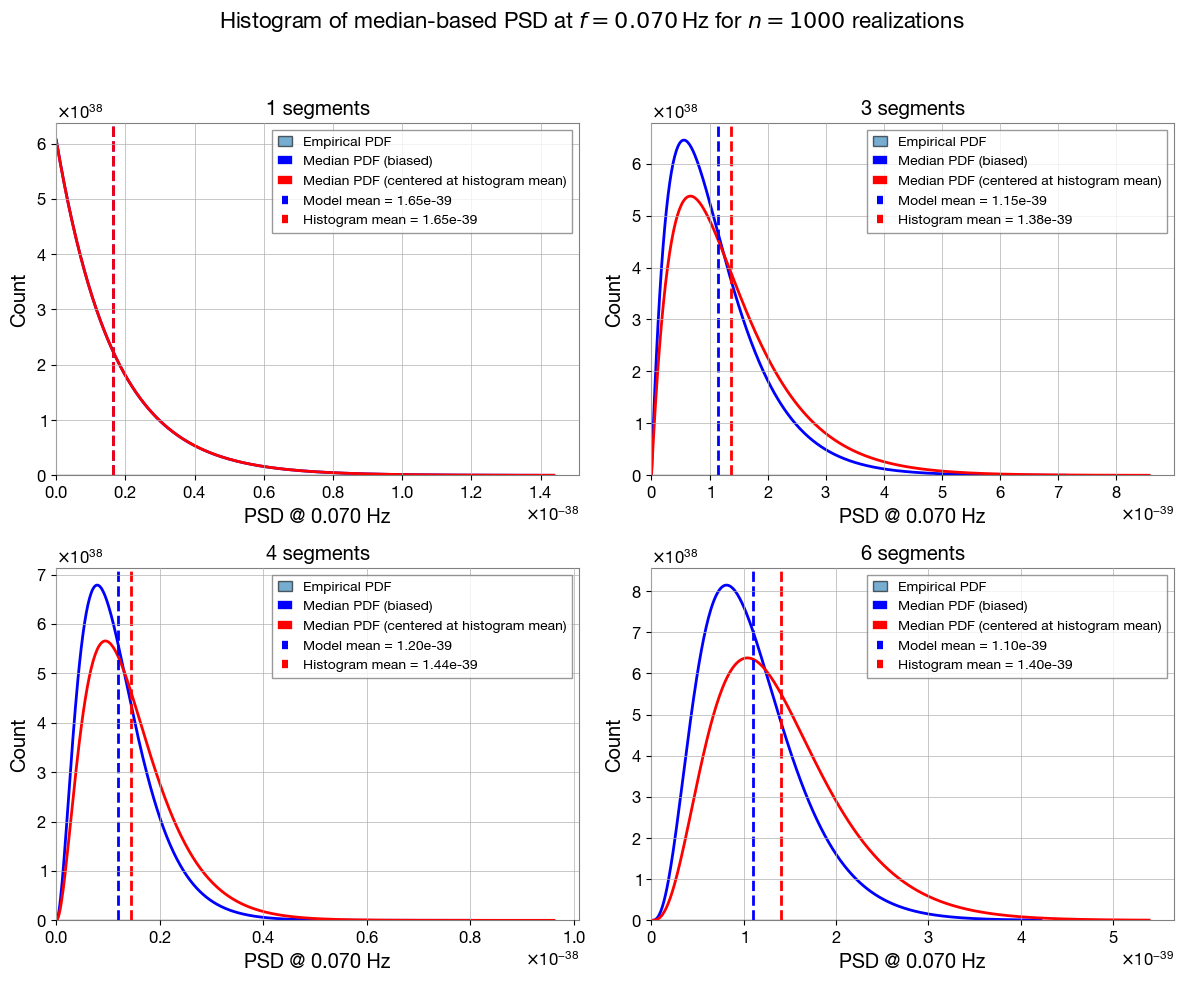

In [4]:
fraction     = 0.7
noverlap     = 0
nperseg_list = [20000, 6000, 5000, 3000]

noise_vals_list = []
freq_list       = []
N_list          = []
seg_counts      = []

for nperseg in nperseg_list:
    f_noise, noise_psds, nseg = n_noise_psds(
        time_noises, fs, nperseg,
        noverlap=noverlap,
        method='median'
    )
    psd_vals, orig_val, chosen_freq, _ = compute_psd_noise_distribution(
        orig_psd, f_orig, noise_psds, f_noise,
        fraction=fraction
    )
    noise_vals_list.append(psd_vals)
    freq_list.append(chosen_freq)
    N_list.append(nseg[0])
    seg_counts.append(nseg[0])

main_title = (
    fr"Histogram of median‐based PSD at $f={freq_list[0]:.3f}\,$Hz "
    fr"for $n={len(noise_vals_list[0])}$ realizations"
)

plot_psd_noise_median_histogram_two_cross_two(
    noise_vals_list,
    freq_list,
    N_list,
    seg_counts,
    median_pdf_fn=median_pdf,
    main_title=main_title,
    n_bins=30
)

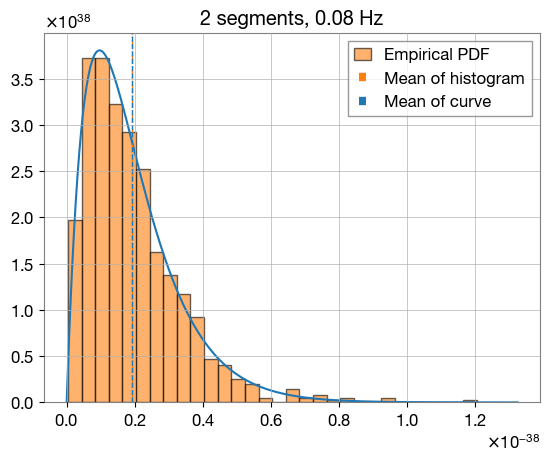

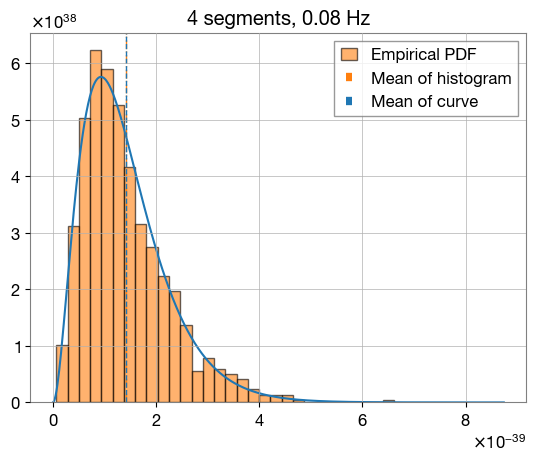

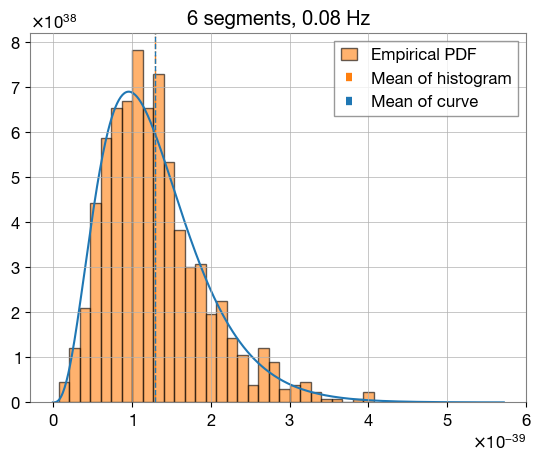

In [5]:
noverlap = 0
fraction = 0.8

nperseg_noise = 10000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

mean_histogram = np.mean(psd_noise_vals)
x = np.linspace(0, psd_noise_vals.max() * 1.1, 500)
N   = nseg[0]                 
pdf = median_pdf(x, N, mean_histogram)
pdf /= np.trapz(pdf, x)   
curve_mean = np.trapz(x * pdf, x)
scale_fac = mean_histogram / curve_mean

x *= scale_fac
pdf /= scale_fac
curve_mean = np.trapz(x * pdf, x)

plt.plot(x, pdf)
plt.hist(psd_noise_vals, bins=30, density=True,
            alpha=0.6, edgecolor='k', label='Empirical PDF')
plt.axvline(mean_histogram, linestyle='-.', color='tab:orange', linewidth=1, label="Mean of histogram")
plt.axvline(curve_mean, linestyle='--', color='C0', linewidth=1, label="Mean of curve")
plt.legend()
plt.title(f'{N} segments, {chosen_f_orig} Hz')
plt.show()


nperseg_noise = 5000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

mean_histogram = np.mean(psd_noise_vals)
x = np.linspace(0, psd_noise_vals.max() * 1.1, 500)
N   = nseg[0]                 
pdf = median_pdf(x, N, mean_histogram)
pdf /= np.trapz(pdf, x)   
curve_mean = np.trapz(x * pdf, x)
scale_fac = mean_histogram / curve_mean

x *= scale_fac
pdf /= scale_fac
curve_mean = np.trapz(x * pdf, x)

plt.plot(x, pdf)
plt.hist(psd_noise_vals, bins=30, density=True,
            alpha=0.6, edgecolor='k', label='Empirical PDF')
plt.axvline(mean_histogram, linestyle='-.', color='tab:orange', linewidth=1, label="Mean of histogram")
plt.axvline(curve_mean, linestyle='--', color='C0', linewidth=1, label="Mean of curve")
plt.legend()
plt.title(f'{N} segments, {chosen_f_orig} Hz')
plt.show()


nperseg_noise = 3000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

mean_histogram = np.mean(psd_noise_vals)
x = np.linspace(0, psd_noise_vals.max() * 1.1, 500)
N   = nseg[0]                 
pdf = median_pdf(x, N, mean_histogram)
pdf /= np.trapz(pdf, x)   
curve_mean = np.trapz(x * pdf, x)
scale_fac = mean_histogram / curve_mean

x *= scale_fac
pdf /= scale_fac
curve_mean = np.trapz(x * pdf, x)

plt.plot(x, pdf)
plt.hist(psd_noise_vals, bins=30, density=True,
            alpha=0.6, edgecolor='k', label='Empirical PDF')
plt.axvline(mean_histogram, linestyle='-.', color='tab:orange', linewidth=1, label="Mean of histogram")
plt.axvline(curve_mean, linestyle='--', color='C0', linewidth=1, label="Mean of curve")
plt.legend()
plt.title(f'{N} segments, {chosen_f_orig} Hz')
plt.show()

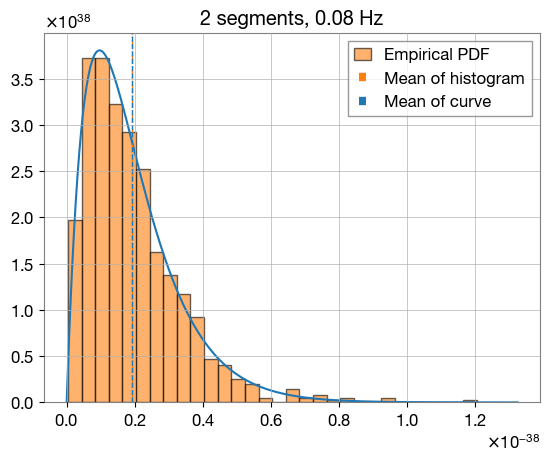

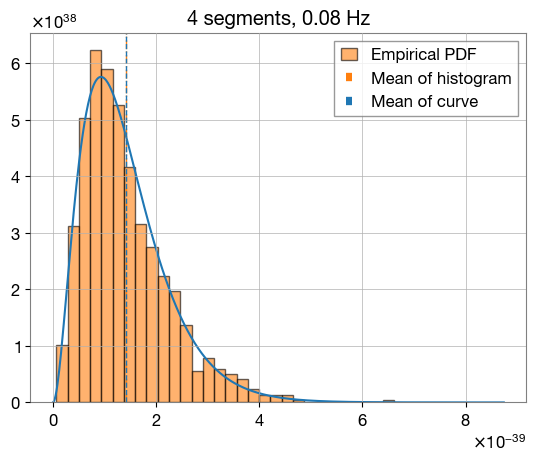

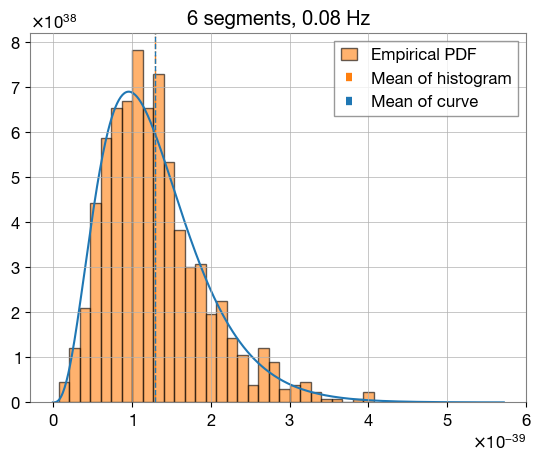

In [12]:
noverlap = 0
fraction = 0.8

nperseg_noise = 10000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

mean_histogram = np.mean(psd_noise_vals)
x = np.linspace(0, psd_noise_vals.max() * 1.1, 500)
N   = nseg[0]                 
pdf = median_pdf(x, N, mean_histogram)
pdf /= np.trapz(pdf, x)   
curve_mean = np.trapz(x * pdf, x)
scale_fac = mean_histogram / curve_mean

x *= scale_fac
pdf /= scale_fac
curve_mean = np.trapz(x * pdf, x)

plt.plot(x, pdf)
plt.hist(psd_noise_vals, bins=30, density=True,
            alpha=0.6, edgecolor='k', label='Empirical PDF')
plt.axvline(mean_histogram, linestyle='-.', color='tab:orange', linewidth=1, label="Mean of histogram")
plt.axvline(curve_mean, linestyle='--', color='C0', linewidth=1, label="Mean of curve")
plt.legend()
plt.title(f'{N} segments, {chosen_f_orig} Hz')
plt.show()


nperseg_noise = 5000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

mean_histogram = np.mean(psd_noise_vals)
x = np.linspace(0, psd_noise_vals.max() * 1.1, 500)
N   = nseg[0]                 
pdf = median_pdf(x, N, mean_histogram)
pdf /= np.trapz(pdf, x)   
curve_mean = np.trapz(x * pdf, x)
scale_fac = mean_histogram / curve_mean

x *= scale_fac
pdf /= scale_fac
curve_mean = np.trapz(x * pdf, x)

plt.plot(x, pdf)
plt.hist(psd_noise_vals, bins=30, density=True,
            alpha=0.6, edgecolor='k', label='Empirical PDF')
plt.axvline(mean_histogram, linestyle='-.', color='tab:orange', linewidth=1, label="Mean of histogram")
plt.axvline(curve_mean, linestyle='--', color='C0', linewidth=1, label="Mean of curve")
plt.legend()
plt.title(f'{N} segments, {chosen_f_orig} Hz')
plt.show()


nperseg_noise = 3000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

mean_histogram = np.mean(psd_noise_vals)
x = np.linspace(0, psd_noise_vals.max() * 1.1, 500)
N   = nseg[0]                 
pdf = median_pdf(x, N, mean_histogram)
pdf /= np.trapz(pdf, x)   
curve_mean = np.trapz(x * pdf, x)
scale_fac = mean_histogram / curve_mean

x *= scale_fac
pdf /= scale_fac
curve_mean = np.trapz(x * pdf, x)

plt.plot(x, pdf)
plt.hist(psd_noise_vals, bins=30, density=True,
            alpha=0.6, edgecolor='k', label='Empirical PDF')
plt.axvline(mean_histogram, linestyle='-.', color='tab:orange', linewidth=1, label="Mean of histogram")
plt.axvline(curve_mean, linestyle='--', color='C0', linewidth=1, label="Mean of curve")
plt.legend()
plt.title(f'{N} segments, {chosen_f_orig} Hz')
plt.show()

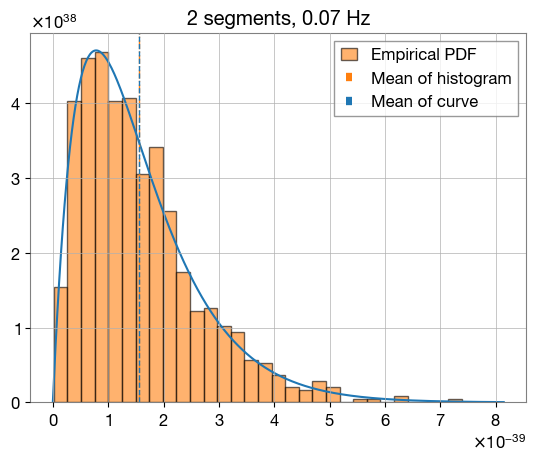

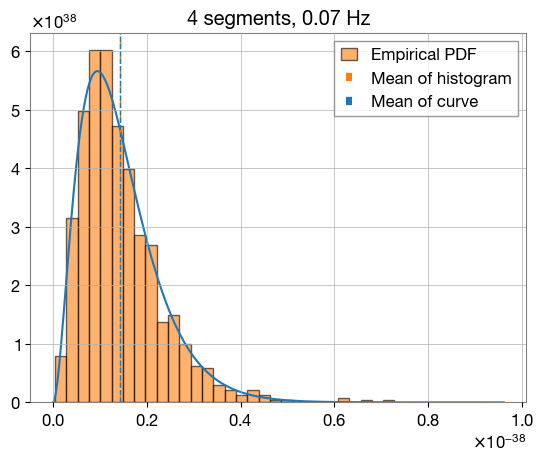

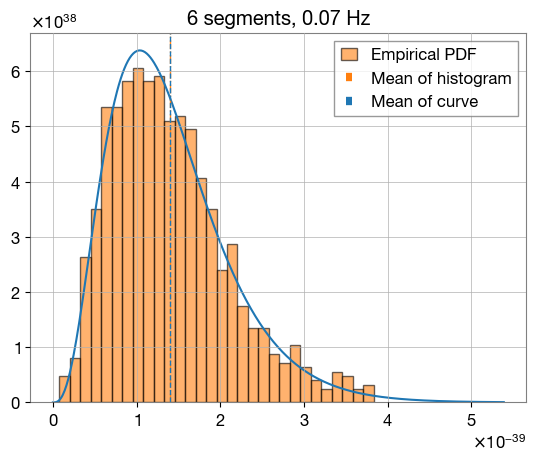

In [6]:
noverlap = 0
fraction = 0.7

nperseg_noise = 10000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

mean_histogram = np.mean(psd_noise_vals)
x = np.linspace(0, psd_noise_vals.max() * 1.1, 500)
N   = nseg[0]                 
pdf = median_pdf(x, N, mean_histogram)
pdf /= np.trapz(pdf, x)   
curve_mean = np.trapz(x * pdf, x)
scale_fac = mean_histogram / curve_mean

x *= scale_fac
pdf /= scale_fac
curve_mean = np.trapz(x * pdf, x)

plt.plot(x, pdf)
plt.hist(psd_noise_vals, bins=30, density=True,
            alpha=0.6, edgecolor='k', label='Empirical PDF')
plt.axvline(mean_histogram, linestyle='-.', color='tab:orange', linewidth=1, label="Mean of histogram")
plt.axvline(curve_mean, linestyle='--', color='C0', linewidth=1, label="Mean of curve")
plt.legend()
plt.title(f'{N} segments, {chosen_f_orig} Hz')
plt.show()


nperseg_noise = 5000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

mean_histogram = np.mean(psd_noise_vals)
x = np.linspace(0, psd_noise_vals.max() * 1.1, 500)
N   = nseg[0]                 
pdf = median_pdf(x, N, mean_histogram)
pdf /= np.trapz(pdf, x)   
curve_mean = np.trapz(x * pdf, x)
scale_fac = mean_histogram / curve_mean

x *= scale_fac
pdf /= scale_fac
curve_mean = np.trapz(x * pdf, x)

plt.plot(x, pdf)
plt.hist(psd_noise_vals, bins=30, density=True,
            alpha=0.6, edgecolor='k', label='Empirical PDF')
plt.axvline(mean_histogram, linestyle='-.', color='tab:orange', linewidth=1, label="Mean of histogram")
plt.axvline(curve_mean, linestyle='--', color='C0', linewidth=1, label="Mean of curve")
plt.legend()
plt.title(f'{N} segments, {chosen_f_orig} Hz')
plt.show()


nperseg_noise = 3000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

mean_histogram = np.mean(psd_noise_vals)
x = np.linspace(0, psd_noise_vals.max() * 1.1, 500)
N   = nseg[0]                 
pdf = median_pdf(x, N, mean_histogram)
pdf /= np.trapz(pdf, x)   
curve_mean = np.trapz(x * pdf, x)
scale_fac = mean_histogram / curve_mean

x *= scale_fac
pdf /= scale_fac
curve_mean = np.trapz(x * pdf, x)

plt.plot(x, pdf)
plt.hist(psd_noise_vals, bins=30, density=True,
            alpha=0.6, edgecolor='k', label='Empirical PDF')
plt.axvline(mean_histogram, linestyle='-.', color='tab:orange', linewidth=1, label="Mean of histogram")
plt.axvline(curve_mean, linestyle='--', color='C0', linewidth=1, label="Mean of curve")
plt.legend()
plt.title(f'{N} segments, {chosen_f_orig} Hz')
plt.show()

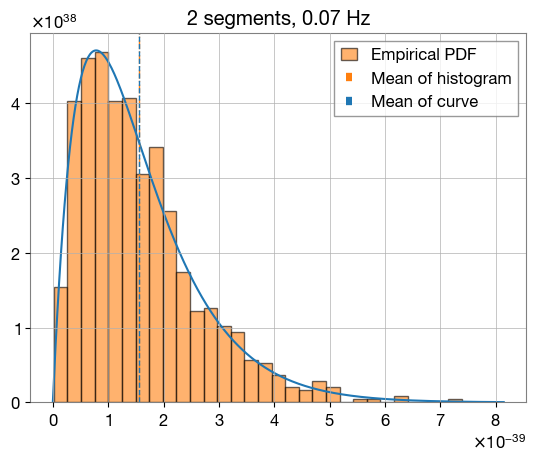

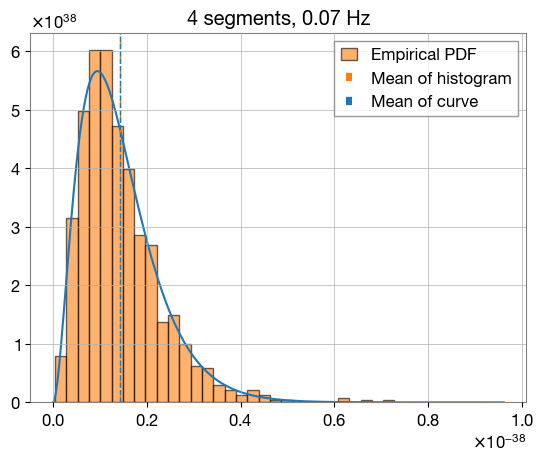

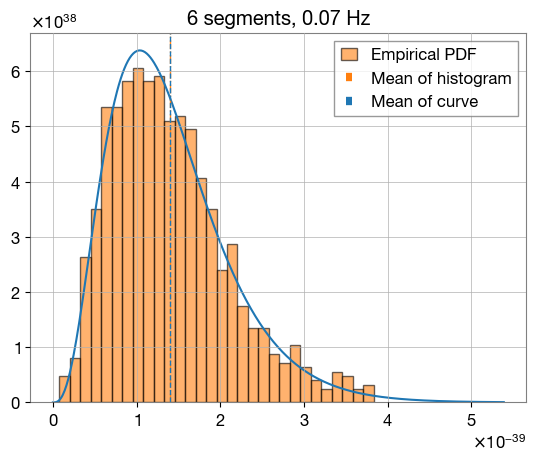

In [13]:
noverlap = 0
fraction = 0.7

nperseg_noise = 10000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

mean_histogram = np.mean(psd_noise_vals)
x = np.linspace(0, psd_noise_vals.max() * 1.1, 500)
N   = nseg[0]                 
pdf = median_pdf(x, N, mean_histogram)
pdf /= np.trapz(pdf, x)   
curve_mean = np.trapz(x * pdf, x)
scale_fac = mean_histogram / curve_mean

x *= scale_fac
pdf /= scale_fac
curve_mean = np.trapz(x * pdf, x)

plt.plot(x, pdf)
plt.hist(psd_noise_vals, bins=30, density=True,
            alpha=0.6, edgecolor='k', label='Empirical PDF')
plt.axvline(mean_histogram, linestyle='-.', color='tab:orange', linewidth=1, label="Mean of histogram")
plt.axvline(curve_mean, linestyle='--', color='C0', linewidth=1, label="Mean of curve")
plt.legend()
plt.title(f'{N} segments, {chosen_f_orig} Hz')
plt.show()


nperseg_noise = 5000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

mean_histogram = np.mean(psd_noise_vals)
x = np.linspace(0, psd_noise_vals.max() * 1.1, 500)
N   = nseg[0]                 
pdf = median_pdf(x, N, mean_histogram)
pdf /= np.trapz(pdf, x)   
curve_mean = np.trapz(x * pdf, x)
scale_fac = mean_histogram / curve_mean

x *= scale_fac
pdf /= scale_fac
curve_mean = np.trapz(x * pdf, x)

plt.plot(x, pdf)
plt.hist(psd_noise_vals, bins=30, density=True,
            alpha=0.6, edgecolor='k', label='Empirical PDF')
plt.axvline(mean_histogram, linestyle='-.', color='tab:orange', linewidth=1, label="Mean of histogram")
plt.axvline(curve_mean, linestyle='--', color='C0', linewidth=1, label="Mean of curve")
plt.legend()
plt.title(f'{N} segments, {chosen_f_orig} Hz')
plt.show()


nperseg_noise = 3000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

mean_histogram = np.mean(psd_noise_vals)
x = np.linspace(0, psd_noise_vals.max() * 1.1, 500)
N   = nseg[0]                 
pdf = median_pdf(x, N, mean_histogram)
pdf /= np.trapz(pdf, x)   
curve_mean = np.trapz(x * pdf, x)
scale_fac = mean_histogram / curve_mean

x *= scale_fac
pdf /= scale_fac
curve_mean = np.trapz(x * pdf, x)

plt.plot(x, pdf)
plt.hist(psd_noise_vals, bins=30, density=True,
            alpha=0.6, edgecolor='k', label='Empirical PDF')
plt.axvline(mean_histogram, linestyle='-.', color='tab:orange', linewidth=1, label="Mean of histogram")
plt.axvline(curve_mean, linestyle='--', color='C0', linewidth=1, label="Mean of curve")
plt.legend()
plt.title(f'{N} segments, {chosen_f_orig} Hz')
plt.show()

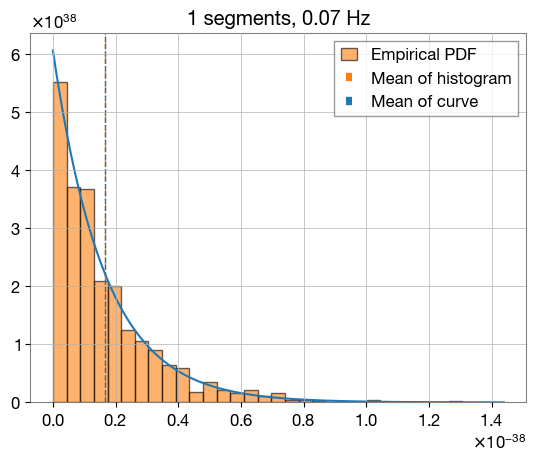

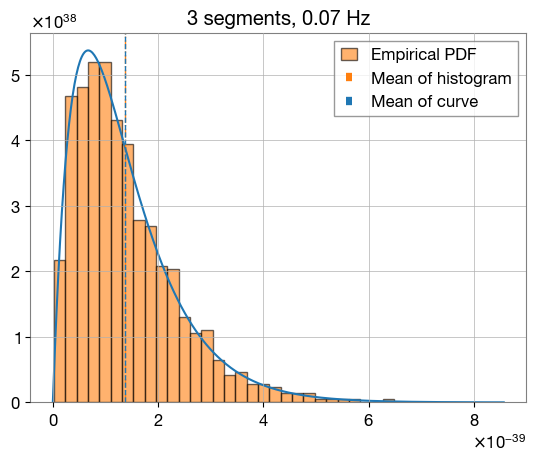

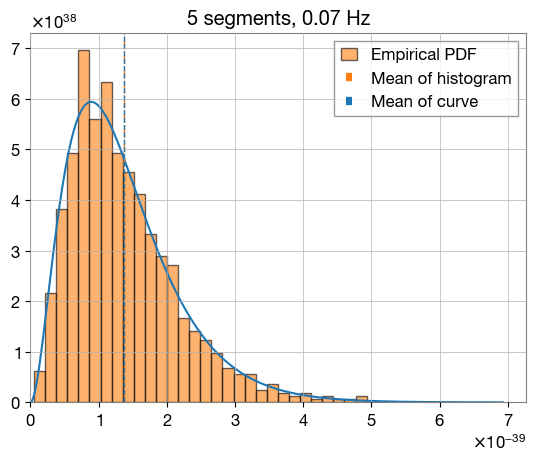

In [19]:
noverlap = 0
fraction = 0.7

nperseg_noise = 20000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

mean_histogram = np.mean(psd_noise_vals)
x = np.linspace(0, psd_noise_vals.max() * 1.1, 500)
N   = nseg[0]                 
pdf = median_pdf(x, N, mean_histogram)
pdf /= np.trapz(pdf, x) 
# print(f"N: {N}")
# print(f"pdf: {pdf}")
# print(f"np.trapz(pdf, x): {np.trapz(pdf, x)}")  
curve_mean = np.trapz(x * pdf, x)
scale_fac = mean_histogram / curve_mean
x *= scale_fac
pdf /= scale_fac
curve_mean = np.trapz(x * pdf, x)
plt.plot(x, pdf)
plt.hist(psd_noise_vals, bins=30, density=True,
            alpha=0.6, edgecolor='k', label='Empirical PDF')
plt.axvline(mean_histogram, linestyle='-.', color='tab:orange', linewidth=1, label="Mean of histogram")
plt.axvline(curve_mean, linestyle='--', color='C0', linewidth=1, label="Mean of curve")
plt.legend()
plt.title(f'{N} segments, {chosen_f_orig} Hz')
plt.show()


nperseg_noise = 6000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
mean_histogram = np.mean(psd_noise_vals)
x = np.linspace(0, psd_noise_vals.max() * 1.1, 500)
N   = nseg[0]                 
pdf = median_pdf(x, N, mean_histogram)
pdf /= np.trapz(pdf, x)   
curve_mean = np.trapz(x * pdf, x)
scale_fac = mean_histogram / curve_mean
x *= scale_fac
pdf /= scale_fac
curve_mean = np.trapz(x * pdf, x)
plt.plot(x, pdf)
plt.hist(psd_noise_vals, bins=30, density=True,
            alpha=0.6, edgecolor='k', label='Empirical PDF')
plt.axvline(mean_histogram, linestyle='-.', color='tab:orange', linewidth=1, label="Mean of histogram")
plt.axvline(curve_mean, linestyle='--', color='C0', linewidth=1, label="Mean of curve")
plt.legend()
plt.title(f'{N} segments, {chosen_f_orig} Hz')
plt.show()


nperseg_noise = 4000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
mean_histogram = np.mean(psd_noise_vals)
x = np.linspace(0, psd_noise_vals.max() * 1.1, 500)
N   = nseg[0]                 
pdf = median_pdf(x, N, mean_histogram)
pdf /= np.trapz(pdf, x)   
curve_mean = np.trapz(x * pdf, x)
scale_fac = mean_histogram / curve_mean
x *= scale_fac
pdf /= scale_fac
curve_mean = np.trapz(x * pdf, x)
plt.plot(x, pdf)
plt.hist(psd_noise_vals, bins=30, density=True,
            alpha=0.6, edgecolor='k', label='Empirical PDF')
plt.axvline(mean_histogram, linestyle='-.', color='tab:orange', linewidth=1, label="Mean of histogram")
plt.axvline(curve_mean, linestyle='--', color='C0', linewidth=1, label="Mean of curve")
plt.legend()
plt.title(f'{N} segments, {chosen_f_orig} Hz')
plt.xlim(left=0)
plt.show()

histogram: [9.36290873e-40 4.43300989e-39 1.33838845e-39 ... 3.28683012e-39
 4.06961188e-39 1.25789373e-39]


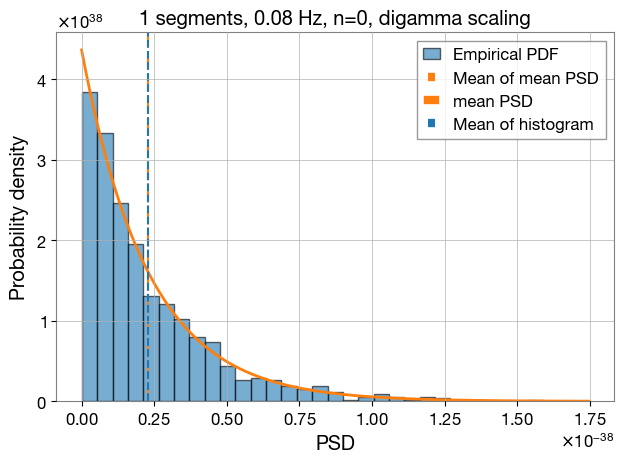

histogram: [8.44671894e-40 6.38646270e-40 8.28152742e-40 ... 2.46060596e-39
 5.63346028e-40 8.50797431e-40]


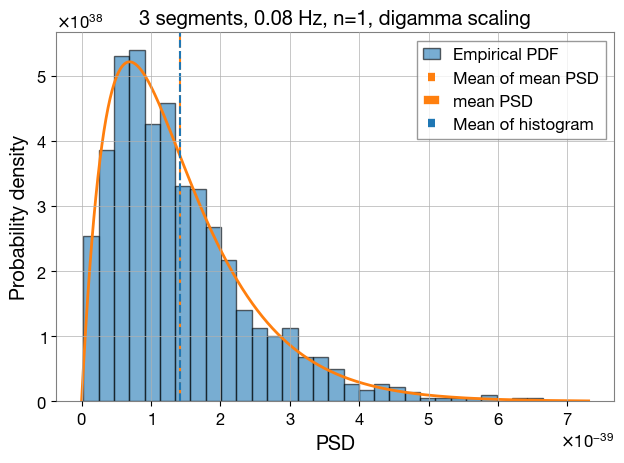

histogram: [8.25628342e-40 2.05969377e-39 9.60284673e-40 ... 9.67785148e-40
 1.94896038e-39 3.54598222e-40]


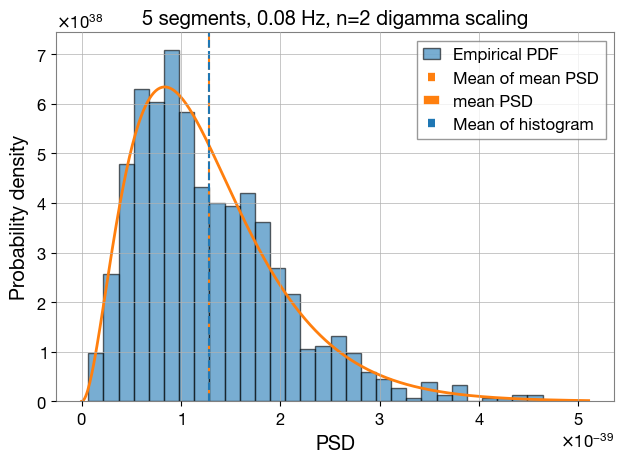

In [14]:
noverlap = 0
fraction = 0.8

nperseg_noise = 20000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

N   = nseg[0]                 
n   = (N - 1)//2
harm = digamma(N + 1) - digamma(n + 1) #  harmonic difference  H_{2n+1} - H_n   # same as sum(1/np.arange(n+1, N+1))

hist_mean = np.mean(psd_noise_vals)      # ⟨median⟩ from your 1000 realisations
lam = hist_mean / harm                  #  << correct scale parameter >>
# lam = hist_mean
plot_median_histogram(psd_noise_vals,
                      N,
                      [lam],            # not hist_mean, but λ!
                      labels=['mean PSD'],
                      title=f'{N} segments, {chosen_f_orig} Hz, n={n}, digamma scaling',
                      n_bins=30)


nperseg_noise = 6000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

N   = nseg[0]                 
n   = (N - 1)//2
harm = digamma(N + 1) - digamma(n + 1) #  harmonic difference  H_{2n+1} - H_n   # same as sum(1/np.arange(n+1, N+1))

hist_mean = np.mean(psd_noise_vals)      # ⟨median⟩ from your 1000 realisations
lam = hist_mean / harm                  #  << correct scale parameter >>
# lam = hist_mean
plot_median_histogram(psd_noise_vals,
                      N,
                      [lam],            # not hist_mean, but λ!
                      labels=['mean PSD'],
                      title=f'{N} segments, {chosen_f_orig} Hz, n={n}, digamma scaling',
                      n_bins=30)



nperseg_noise = 4000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

N   = nseg[0]                 
n   = (N - 1)//2
harm = digamma(N + 1) - digamma(n + 1) #  harmonic difference  H_{2n+1} - H_n   # same as sum(1/np.arange(n+1, N+1))

hist_mean = np.mean(psd_noise_vals)      # ⟨median⟩ from your 1000 realisations
lam = hist_mean / harm                  #  << correct scale parameter >>
# lam = hist_mean
plot_median_histogram(psd_noise_vals,
                      N,
                      [lam],            # not hist_mean, but λ!
                      labels=['mean PSD'],
                      title=f'{N} segments, {chosen_f_orig} Hz, n={n} digamma scaling',
                      n_bins=30)

histogram: [2.87746465e-39 3.32035335e-39 2.68692250e-40 ... 3.62193357e-39
 1.58908970e-39 8.77062033e-40]


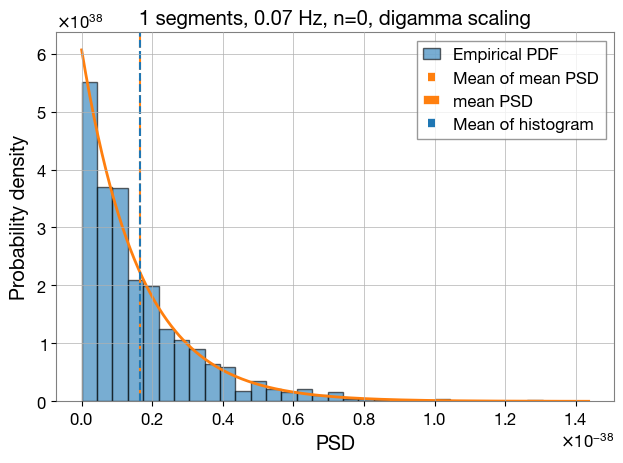

histogram: [1.79665109e-39 1.03698604e-39 1.37557470e-39 ... 1.57607939e-39
 9.29709305e-40 2.27433534e-39]


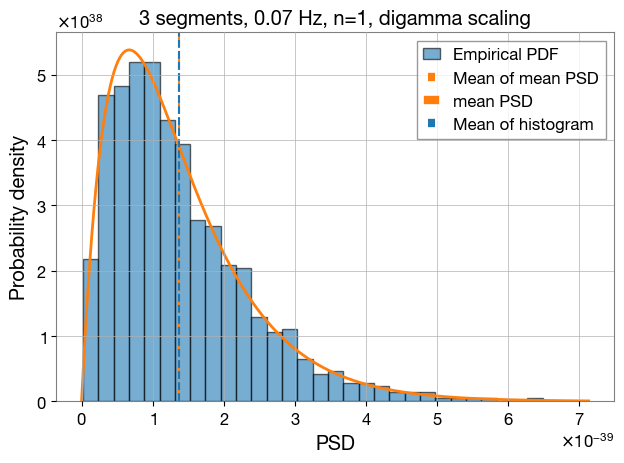

histogram: [1.22651738e-39 2.20589227e-39 8.27390130e-40 ... 2.15896404e-39
 3.07172521e-40 1.30995148e-39]


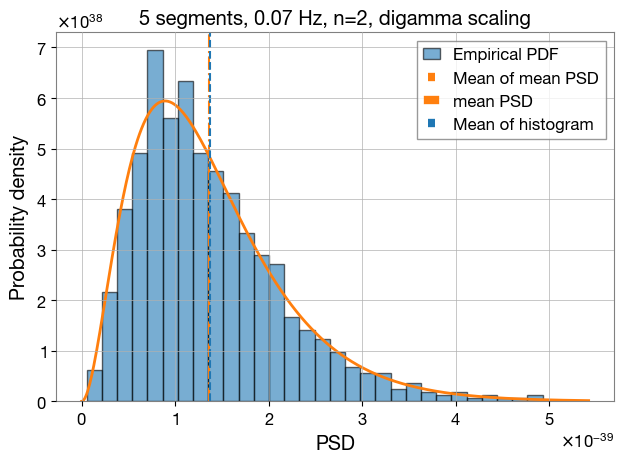

1.7924138271800836e-39


In [10]:
noverlap = 0
fraction = 0.7

nperseg_noise = 20000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

N   = nseg[0]                 
n   = (N - 1)//2
harm = digamma(N + 1) - digamma(n + 1) #  harmonic difference  H_{2n+1} - H_n   # same as sum(1/np.arange(n+1, N+1))

hist_mean = np.mean(psd_noise_vals)      # ⟨median⟩ from your 1000 realisations
lam = hist_mean / harm                  #  << correct scale parameter >>
plot_median_histogram(psd_noise_vals,
                      N,
                      [lam],            # not hist_mean, but λ!
                      labels=['mean PSD'],
                      title=f'{N} segments, {chosen_f_orig} Hz, n={n}, digamma scaling',
                      n_bins=30)


nperseg_noise = 6000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

N   = nseg[0]                 
n   = (N - 1)//2
harm = digamma(N + 1) - digamma(n + 1) #  harmonic difference  H_{2n+1} - H_n   # same as sum(1/np.arange(n+1, N+1))

hist_mean = np.mean(psd_noise_vals)      # ⟨median⟩ from your 1000 realisations
lam = hist_mean / harm                  #  << correct scale parameter >>
plot_median_histogram(psd_noise_vals,
                      N,
                      [lam],            # not hist_mean, but λ!
                      labels=['mean PSD'],
                      title=f'{N} segments, {chosen_f_orig} Hz, n={n}, digamma scaling',
                      n_bins=30)



nperseg_noise = 4000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

N   = nseg[0]                 
n   = (N - 1)//2
harm = digamma(N + 1) - digamma(n + 1) #  harmonic difference  H_{2n+1} - H_n   # same as sum(1/np.arange(n+1, N+1))

hist_mean = np.mean(psd_noise_vals)      # ⟨median⟩ from your 1000 realisations
lam = hist_mean / harm                  #  << correct scale parameter >>
plot_median_histogram(psd_noise_vals,
                      N,
                      [lam],            # not hist_mean, but λ!
                      labels=['mean PSD'],
                      title=f'{N} segments, {chosen_f_orig} Hz, n={n}, digamma scaling',
                      n_bins=30)
print(orig_psd_val)

histogram: [2.87746465e-39 3.32035335e-39 2.68692250e-40 ... 3.62193357e-39
 1.58908970e-39 8.77062033e-40]


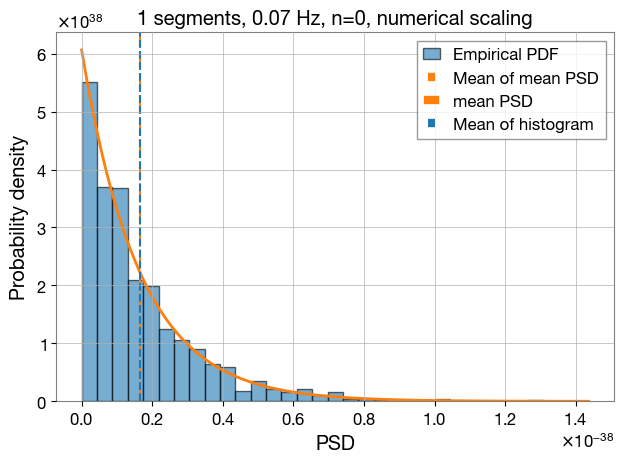

histogram: [1.79665109e-39 1.03698604e-39 1.37557470e-39 ... 1.57607939e-39
 9.29709305e-40 2.27433534e-39]


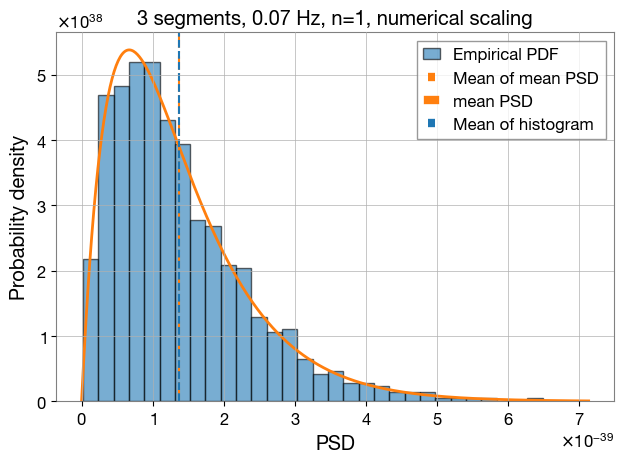

histogram: [1.22651738e-39 2.20589227e-39 8.27390130e-40 ... 2.15896404e-39
 3.07172521e-40 1.30995148e-39]


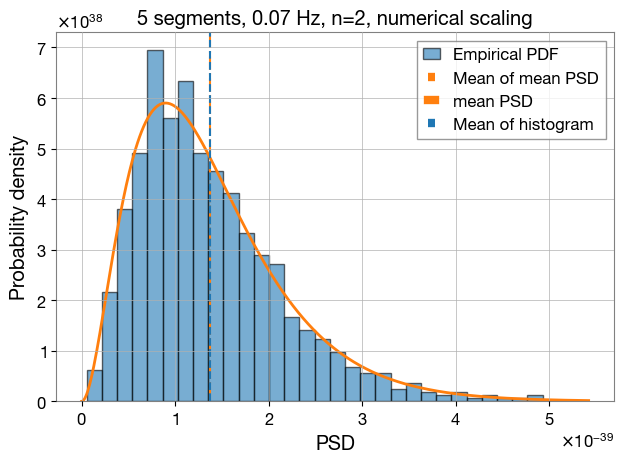

1.7924138271800836e-39


In [11]:
noverlap = 0
fraction = 0.7

nperseg_noise = 20000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

N   = nseg[0]                 
n   = (N - 1)//2
scale_fac = ratio_numerical(n) 
hist_mean = np.mean(psd_noise_vals)      # ⟨median⟩ from your 1000 realisations
lam = hist_mean / scale_fac                  
plot_median_histogram(psd_noise_vals,
                      N,
                      [lam],            # not hist_mean, but λ!
                      labels=['mean PSD'],
                      title=f'{N} segments, {chosen_f_orig} Hz, n={n}, numerical scaling',
                      n_bins=30)


nperseg_noise = 6000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

N   = nseg[0]                 
n   = (N - 1)//2
scale_fac = ratio_numerical(n) 
hist_mean = np.mean(psd_noise_vals)      # ⟨median⟩ from your 1000 realisations
lam = hist_mean / scale_fac                  #  << correct scale parameter >>
plot_median_histogram(psd_noise_vals,
                      N,
                      [lam],            # not hist_mean, but λ!
                      labels=['mean PSD'],
                      title=f'{N} segments, {chosen_f_orig} Hz, n={n}, numerical scaling',
                      n_bins=30)



nperseg_noise = 4000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

N   = nseg[0]                 
n   = (N - 1)//2
harm = digamma(N + 1) - digamma(n + 1) #  harmonic difference  H_{2n+1} - H_n   # same as sum(1/np.arange(n+1, N+1))
scale_fac = ratio_numerical(n)       
lam = hist_mean / scale_fac                  
plot_median_histogram(psd_noise_vals,
                      N,
                      [lam],            # not hist_mean, but λ!
                      labels=['mean PSD'],
                      title=f'{N} segments, {chosen_f_orig} Hz, n={n}, numerical scaling',
                      n_bins=30)
print(orig_psd_val)

[10 10 10 ... 10 10 10]


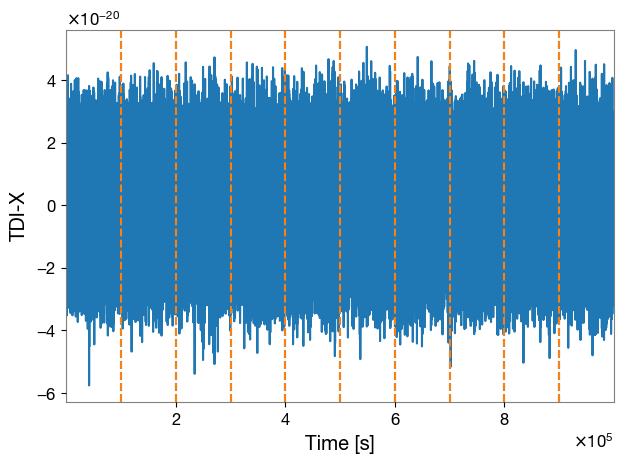

TypeError: 'int' object is not iterable

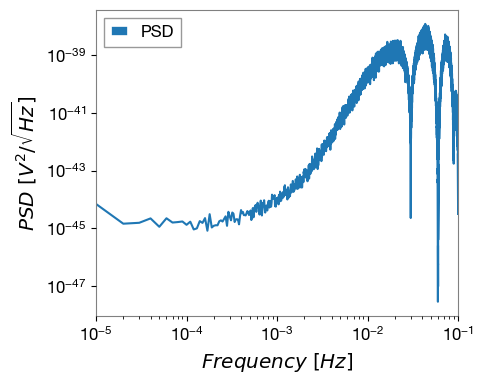

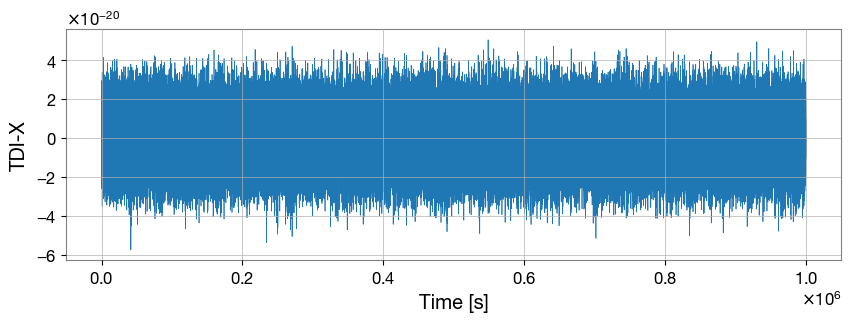

In [3]:
# 1) Read the TDI time series
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
# nperseg = nperseg * 10
f_orig, orig_psd, P_stack, nseg = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg,
    noverlap=0
) 
f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
print(nseg)
# Plot the original psd for no reason 
# draw_segments(t, data, nperseg, 0)
draw_segments(t, data, nperseg, 0)

plot(data=data, t=t, f=f_orig, psd=[orig_psd_median], labels=["PSD"], title="TDI-X", show_time_series=False, f_lims=[f_orig[1], f_orig[-1]])

AttributeError: 'int' object has no attribute 'shape'

Text(0, 0.5, 'Amplitude')

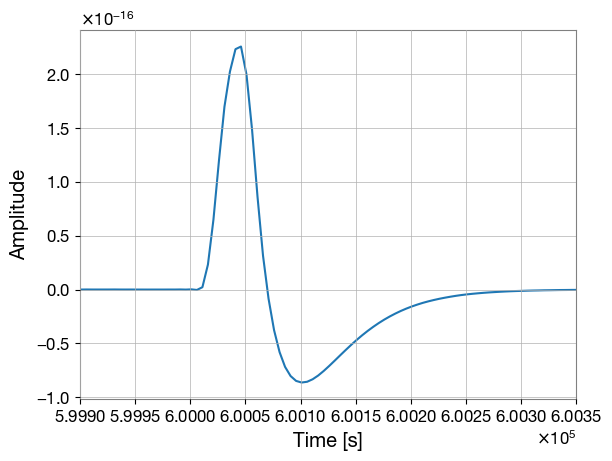

In [ ]:
# 1) Read the TDI time series
tdi_path = getTdiPath('large_glitch_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
# Plot the original psd for no reason 
# plot(
#     data=data,
#     t=t, 
#     fs=fs, 
#     f=f_orig, 
#     nper=nperseg, 
#     psd= [orig_psd, orig_psd_mean],
#     labels= ["no glitch", "glitch"],
#     title="TDI-X", 
#     bigtitle="PSD graphs"
# )

import matplotlib.pyplot as plt
plt.plot(t, data)

plt.xlim(600000-100, 600000+350)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Time series'}, xlabel='Time [s]', ylabel='TDI-X'>,
        <Axes: xlabel='Frequency [Hz]', ylabel='PSD (LISA)'>],
       dtype=object))

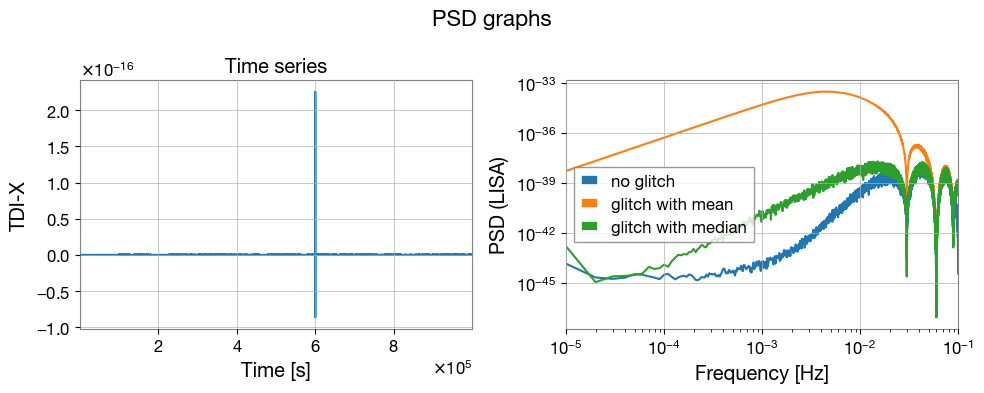

In [ ]:
# 1) Read the TDI time series
tdi_path = getTdiPath('large_glitch_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
# Plot the original psd for no reason 
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_orig, 
    nper=nperseg, 
    psd= [orig_psd, orig_psd_mean, orig_psd_median],
    labels= ["no glitch", "glitch with mean", "glitch with median"],
    title="TDI-X", 
    bigtitle="PSD graphs"
)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Time series'}, xlabel='Time [s]', ylabel='TDI-X'>,
        <Axes: xlabel='Frequency [Hz]', ylabel='PSD (LISA)'>],
       dtype=object))

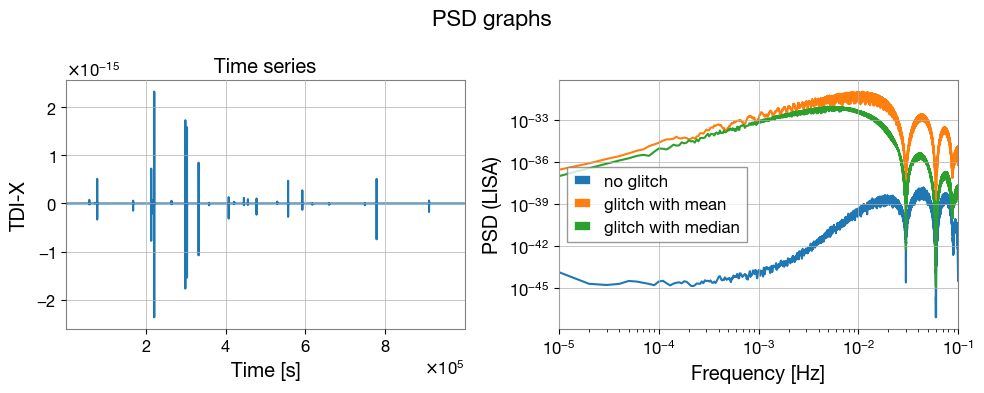

In [ ]:
# 1) Read the TDI time series
tdi_path = getTdiPath('large_glitch_pos_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
# Plot the original psd for no reason 
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_orig, 
    nper=nperseg, 
    psd= [orig_psd, orig_psd_mean, orig_psd_median],
    labels= ["no glitch", "glitch with mean", "glitch with median"],
    title="TDI-X", 
    bigtitle="PSD graphs"
)


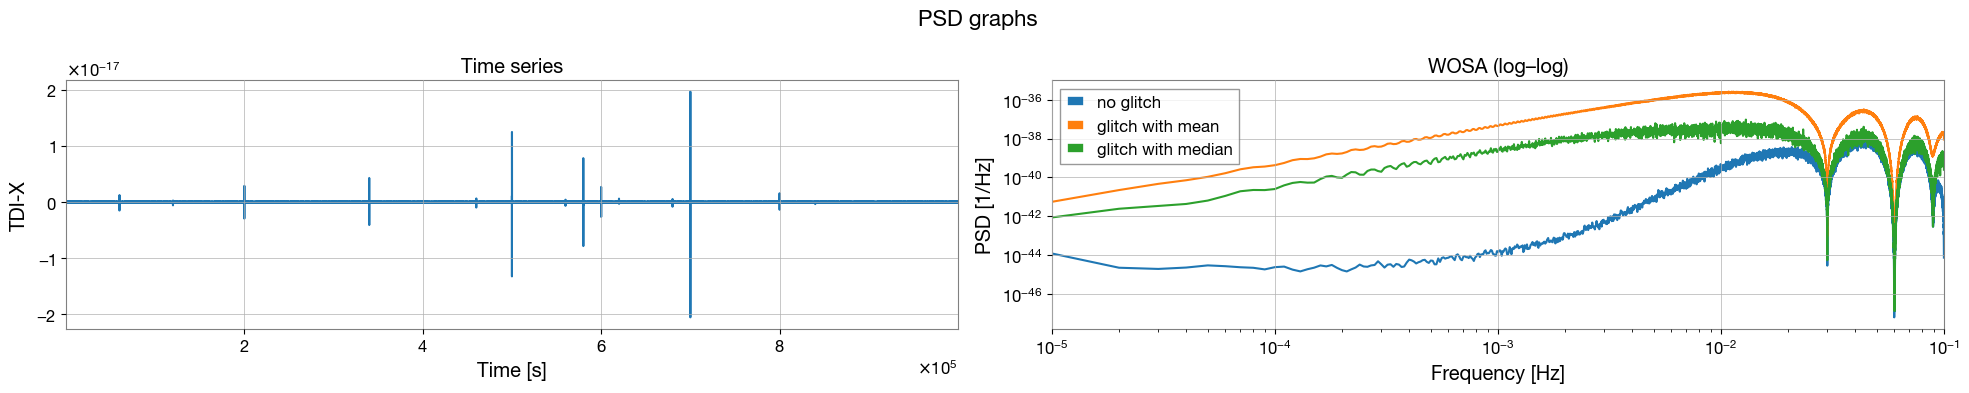

In [ ]:

# 1) Read the TDI time series
tdi_path = getTdiPath('medium_glitch_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
# Plot the original psd for no reason 
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_orig, 
    nper=nperseg, 
    psd= [orig_psd, orig_psd_mean, orig_psd_median],
    labels= ["no glitch", "glitch with mean", "glitch with median"],
    title="TDI-X", 
    bigtitle="PSD graphs"
)

